<a href="https://colab.research.google.com/github/mariamalaa76/Diabetes_RAG_Hackathon/blob/main/day2_retrieval_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q --upgrade langchain langchain-community langchain-core langchain-text-splitters chromadb fastembed pypdf pandas openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.0/147.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.0/567.0 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.9/382.9 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.

In [2]:
import os
import glob
import json
import zipfile
from datetime import datetime
from itertools import product

import pandas as pd
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import FastEmbedEmbeddings

pd.set_option("display.max_colwidth", 120)

print("Imports OK —", datetime.now().isoformat(timespec="seconds"))

/tmp/ipykernel_1654/2742297198.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma


Imports OK — 2026-08-18T05:15:28


In [8]:
ZIP_PATH = "/content/drive/MyDrive/chroma_databases.zip"
EXTRACT_DIR = "/content"

try:
    from google.colab import drive
    drive.mount('/content/drive')

    if os.path.exists(ZIP_PATH):
        with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        print("Unzipped Chroma databases successfully!")
    else:
        print(f"WARNING: Zip file not found at {ZIP_PATH}")
except ImportError:
    print("Not running in Colab — skipping drive mount.")

print("\nFiles/Directories in /content:")
print([f for f in os.listdir(EXTRACT_DIR) if "chroma" in f or "db" in f])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzipped Chroma databases successfully!

Files/Directories in /content:
['chroma_db_baseline_recursive']


In [9]:
found_dbs = sorted(glob.glob(os.path.join(EXTRACT_DIR, "**", "chroma_db_*"), recursive=True))
print("\nLocated Chroma DB Paths:")
for d in found_dbs:
    print(" -", d)

COLLECTIONS = {}
for d in found_dbs:
    folder_name = os.path.basename(d)
    collection_name = folder_name.replace("chroma_db_", "")
    COLLECTIONS[collection_name] = d

print("\nResolved COLLECTIONS dictionary:")
print(json.dumps(COLLECTIONS, indent=2))
EMBED_MODEL = FastEmbedEmbeddings(model_name="BAAI/bge-base-en-v1.5")
print("\nLoaded embedding model:", EMBED_MODEL.model_name)


Located Chroma DB Paths:
 - /content/chroma_db_baseline_recursive
 - /content/content/chroma_db_baseline_recursive
 - /content/content/chroma_db_exp_header
 - /content/content/chroma_db_exp_paragraph

Resolved COLLECTIONS dictionary:
{
  "baseline_recursive": "/content/content/chroma_db_baseline_recursive",
  "exp_header": "/content/content/chroma_db_exp_header",
  "exp_paragraph": "/content/content/chroma_db_exp_paragraph"
}

Loaded embedding model: BAAI/bge-base-en-v1.5


In [10]:
def load_vectorstore(collection_name: str) -> Chroma:
    return Chroma(
        collection_name=collection_name,
        embedding_function=EMBED_MODEL,
        persist_directory=COLLECTIONS[collection_name],
        collection_metadata={"hnsw:space": "cosine"},
    )

### Vector DB readiness check


In [13]:
REQUIRED_METADATA_FIELDS = ["document_name", "page_number", "chunk_id", "strategy"]

def readiness_check(vectorstore: Chroma, collection_name: str, sample_size: int = 200) -> dict:
    """Validate that a Chroma collection is non-empty and core metadata is complete."""
    raw = vectorstore._collection.get(limit=sample_size, include=["metadatas", "documents"])
    metadatas = raw.get("metadatas", [])
    documents = raw.get("documents", [])

    total_count = vectorstore._collection.count()
    missing_field_counts = {field: 0 for field in REQUIRED_METADATA_FIELDS}
    missing_field_counts["section (optional)"] = 0
    empty_text_count = 0

    for meta, doc_text in zip(metadatas, documents):
        # Check required fields
        for field in REQUIRED_METADATA_FIELDS:
            if field not in meta or meta[field] in (None, "", "unknown"):
                missing_field_counts[field] += 1

        # Check optional section
        if "section" not in meta or meta["section"] in (None, "", "unknown"):
            missing_field_counts["section (optional)"] += 1

        if not doc_text or not doc_text.strip():
            empty_text_count += 1

    # Schema is OK if strictly required core fields have 0 missing values
    core_schema_ok = all(missing_field_counts[f] == 0 for f in REQUIRED_METADATA_FIELDS)

    return {
        "collection": collection_name,
        "total_chunks": total_count,
        "sampled": len(metadatas),
        "missing_field_counts": missing_field_counts,
        "empty_text_chunks_in_sample": empty_text_count,
        "schema_ok": core_schema_ok,
        "non_empty": total_count > 0,
    }

In [14]:
# Run readiness check across all available collections
readiness_reports = []
for name, path in COLLECTIONS.items():
    if os.path.isdir(path):
        vs = load_vectorstore(name)
        readiness_reports.append(readiness_check(vs, name))
    else:
        readiness_reports.append({
            "collection": name,
            "total_chunks": 0,
            "sampled": 0,
            "missing_field_counts": {},
            "empty_text_chunks_in_sample": 0,
            "schema_ok": False,
            "non_empty": False,
        })

# Display report in DataFrame format
readiness_df = pd.DataFrame(readiness_reports)
display(readiness_df)

# Evaluate system readiness
all_ready = readiness_df["schema_ok"].all() and readiness_df["non_empty"].all()

print("=" * 60)
if all_ready:
    print("READY: All collections are non-empty and metadata-complete.")
    print("Proceeding to retrieval optimization.")
else:
    print("NOT READY: Fix parsing, chunking, metadata, or indexing before tuning.")
    display(readiness_df[~(readiness_df['schema_ok'] & readiness_df['non_empty'])])
print("=" * 60)

,collection,total_chunks,sampled,missing_field_counts,empty_text_chunks_in_sample,schema_ok,non_empty
0,baseline_recursive,283,200,"{'document_name': 0, 'page_number': 0, 'chunk_id': 0, 'strategy': 0, 'section (optional)': 3}",0,True,True
1,exp_header,239,200,"{'document_name': 0, 'page_number': 0, 'chunk_id': 0, 'strategy': 0, 'section (optional)': 36}",0,True,True
2,exp_paragraph,195,195,"{'document_name': 0, 'page_number': 0, 'chunk_id': 0, 'strategy': 0, 'section (optional)': 0}",0,True,True


READY: All collections are non-empty and metadata-complete.
Proceeding to retrieval optimization.


## Clinical Evaluation Set (20 Questions)

In [15]:
# 1. Define the 20 clinical evaluation questions dataset
EVAL_QUESTIONS = [
    dict(id=1, question="What is the target HbA1c for adults with type 1 diabetes?",
         category="Supported", diabetes_type="Type 1", expected_topic="HbA1c target",
         expected_guideline="NG17", expected_pages="18",
         note="Unambiguous, single-guideline, single numeric value (48 mmol/mol / 6.5%)."),
    dict(id=2, question="What is the preferred insulin regimen for adults newly diagnosed with type 1 diabetes?",
         category="Supported", diabetes_type="Type 1", expected_topic="Insulin regimen choice",
         expected_guideline="NG17", expected_pages="24",
         note="Correct answer must name 'basal-bolus' (multiple daily injections), not generic 'insulin therapy'."),
    dict(id=3, question="What clinical signs suggest someone might have type 1 diabetes?",
         category="Supported", diabetes_type="Type 1", expected_topic="Diagnostic signs",
         expected_guideline="NG17", expected_pages="6",
         note="Should list several of the 5 signs; must not overstate age/BMI as definitive."),
    dict(id=4, question="What should be done for someone with type 1 diabetes who no longer feels their hypoglycaemia symptoms?",
         category="Supported", diabetes_type="Type 1", expected_topic="Impaired hypoglycaemia awareness management",
         expected_guideline="NG17", expected_pages="30",
         note="Correct: annual Gold/Clarke assessment, education, pump/rtCGM escalation."),
    dict(id=5, question="What is usually the first medicine given for type 2 diabetes with no other health problems?",
         category="Supported", diabetes_type="Type 2", expected_topic="First-line pharmacological treatment",
         expected_guideline="NG28", expected_pages="32",
         note="Metformin (+ SGLT-2 inhibitor) is first-line; must not default to insulin."),
    dict(id=6, question="What treatment is recommended for someone with type 2 diabetes and heart failure?",
         category="Supported", diabetes_type="Type 2", expected_topic="Comorbidity-specific treatment (cardiovascular)",
         expected_guideline="NG28", expected_pages="40",
         note="Metformin + SGLT-2 inhibitor (or SGLT-2 monotherapy). Must name SGLT-2 specifically."),
    dict(id=7, question="What should be checked before starting someone on an SGLT-2 inhibitor?",
         category="Supported", diabetes_type="Type 2", expected_topic="Pre-treatment safety screening (DKA risk)",
         expected_guideline="NG28", expected_pages="70",
         note="Safety-critical: DKA risk factors (prior DKA, illness, dehydration, low-carb/ketogenic diet)."),
    dict(id=8, question="How often should someone with diabetes get their HbA1c checked?",
         category="Supported", diabetes_type="Both", expected_topic="Monitoring frequency",
         expected_guideline="NG17 + NG28", expected_pages="17 (NG17), 12 (NG28)",
         note="Both converge on 3-6 months; NG28 allows extending to 6 months once stable."),
    dict(id=9, question="Should someone with diabetes take aspirin to prevent heart disease?",
         category="Supported", diabetes_type="Both", expected_topic="Cardiovascular primary prevention",
         expected_guideline="NG17 + NG28", expected_pages="35 (NG17), 119 (NG28)",
         note="Both guidelines recommend AGAINST aspirin for primary prevention."),
    dict(id=10, question="What is the first medicine usually given to someone newly diagnosed with diabetes?",
         category="Difficult Type 1 vs Type 2", diabetes_type="Both", expected_topic="First-line treatment (type-dependent)",
         expected_guideline="NG17 (p.24) or NG28 (p.32)", expected_pages="24 or 32",
         note="TRAP: answer differs entirely by type. System should ask which type or answer both."),
    dict(id=11, question="Can metformin be used to treat type 1 diabetes?",
         category="Difficult Type 1 vs Type 2", diabetes_type="Type 1", expected_topic="Adjunct therapy nuance",
         expected_guideline="NG17", expected_pages="29",
         note="TRAP: naive 'no' is WRONG. NG17 1.7.26 allows metformin as adjunct to insulin for BMI>=25."),
    dict(id=12, question="Is continuous glucose monitoring (CGM) offered the same way to type 1 and type 2 diabetes patients?",
         category="Difficult Type 1 vs Type 2", diabetes_type="Both", expected_topic="CGM eligibility criteria",
         expected_guideline="NG17 (p.18) + NG28 (p.14-15)", expected_pages="18 (NG17), 14-15 (NG28)",
         note="TRAP: NG17 offers CGM to ALL type 1 adults; NG28 is criteria-based for type 2."),
    dict(id=13, question="Should someone with diabetes use an insulin pump?",
         category="Difficult Type 1 vs Type 2", diabetes_type="Type 1", expected_topic="Insulin pump (CSII) eligibility",
         expected_guideline="NG17", expected_pages="28",
         note="TRAP: NG17 references TA151 for CSII in type 1; NG28 has no equivalent pathway."),
    dict(id=14, question="What blood sugar level should I aim for before meals?",
         category="Ambiguous", diabetes_type="Type not specified by user", expected_topic="Pre-meal glucose target",
         expected_guideline="NG17 (p.23) or NG28", expected_pages="23 (NG17)",
         note="No type stated. Correct behavior: ask which type, or present both."),
    dict(id=15, question="How often should I check my blood sugar every day?",
         category="Ambiguous", diabetes_type="Type not specified by user", expected_topic="Self-monitoring frequency",
         expected_guideline="NG17 (p.22-23) or NG28 (p.14)", expected_pages="22-23 (NG17)",
         note="Depends on type AND regimen. A confident single-number answer signals oversimplification."),
    dict(id=16, question="What treatment should I take for my diabetes?",
         category="Ambiguous", diabetes_type="Type not specified by user", expected_topic="Treatment (too broad)",
         expected_guideline="Cannot be determined from the question alone", expected_pages="N/A",
         note="Deliberately under-specified. Correct behavior is to ask a clarifying question."),
    dict(id=17, question="Is aspirin safe for someone with diabetes?",
         category="Ambiguous", diabetes_type="Both", expected_topic="Aspirin safety vs. primary-prevention recommendation",
         expected_guideline="NG17 (p.35) + NG28 (p.119)", expected_pages="35 (NG17), 119 (NG28)",
         note="Subtly different from Q9: 'safe' != 'recommended for prevention'."),
    dict(id=18, question="How much do diabetes medicines cost in Egypt?",
         category="Out of scope", diabetes_type="Out of scope", expected_topic="Local medicine pricing",
         expected_guideline="None", expected_pages="N/A",
         note="Neither guideline has pricing data. Correct behavior: explicit refusal."),
    dict(id=19, question="Is there an approved gene therapy for diabetes?",
         category="Out of scope", diabetes_type="Out of scope", expected_topic="Experimental/future treatment",
         expected_guideline="None", expected_pages="N/A",
         note="Not covered by either guideline. Any specific claim here is fabricated."),
    dict(id=20, question="Can type 1 diabetes be prevented through diet?",
         category="Out of scope", diabetes_type="Out of scope", expected_topic="Prevention (vs. management)",
         expected_guideline="None", expected_pages="N/A",
         note="Guidelines cover management of existing diabetes, not prevention."),
]

# 2. Convert to DataFrame and verify category distribution
eval_df = pd.DataFrame(EVAL_QUESTIONS)
print(f"Loaded {len(eval_df)} evaluation questions.")

# Display question count per category
display(eval_df.groupby("category").size().rename("count").to_frame())

Loaded 20 evaluation questions.


,count
category,
Ambiguous,4
Difficult Type 1 vs Type 2,4
Out of scope,3
Supported,9


In [16]:
EVAL_XLSX_PATH = "/content/Diabetes_RAG_Evaluation.xlsx"

if os.path.exists(EVAL_XLSX_PATH):
    eval_xlsx_df = pd.read_excel(EVAL_XLSX_PATH, sheet_name="Evaluation Dataset")
    match_status = "MATCH" if len(eval_xlsx_df) == len(eval_df) else "MISMATCH"

    print(f"Excel loaded: {len(eval_xlsx_df)} rows | Status: {match_status}")
    display(eval_xlsx_df.head(3))
else:
    print("Excel file not found. Using the hardcoded EVAL_QUESTIONS list.")

Excel loaded: 20 rows | Status: MATCH


,#,Question,Category,Diabetes Type,Expected Topic,Expected Guideline,Expected Page(s),Clinical Validation Note
0,1,What is the target HbA1c for adults with type 1 diabetes?,Supported,Type 1,HbA1c target,NG17,18,"NG17 rec 1.6.6 states an explicit numeric target (48 mmol/mol / 6.5%). Unambiguous, single-guideline, single-value f..."
1,2,What is the preferred insulin regimen for adults newly diagnosed with type 1 diabetes?,Supported,Type 1,Insulin regimen choice,NG17,24,NG17 rec 1.7.1-1.7.2: multiple daily injection basal-bolus is the regimen of choice; non-basal-bolus regimens are ex...
2,3,What clinical signs suggest someone might have type 1 diabetes?,Supported,Type 1,Diagnostic signs,NG17,6,"NG17 rec 1.1.1 lists 5 specific signs (ketosis, rapid weight loss, age <50, BMI <25, autoimmune history). A correct ..."


## Run Retrieval & Compare Top-K Strategies (K = 3, 5, 10)


In [17]:
# Definition of K values for retrieval evaluation
K_VALUES = [3, 5, 10]

def retrieve_for_question(vectorstore: Chroma, question: str, k: int) -> list[dict]:
    """Run similarity search and return structured result records."""
    results = vectorstore.similarity_search_with_relevance_scores(question, k=k)
    records = []

    for rank, (doc, score) in enumerate(results, start=1):
        doc_name = doc.metadata.get("document_name", "N/A")
        page_num = doc.metadata.get("page_number", "N/A")
        chunk_id = doc.metadata.get("chunk_id", "N/A")

        records.append({
            "rank": rank,
            "score": round(float(score), 4),
            "document_name": doc_name,
            "section": doc.metadata.get("section", "N/A"),
            "page_number": page_num,
            "chunk_id": chunk_id,
            "strategy": doc.metadata.get("strategy", "baseline"),
            "citation": f"[{doc_name} | p.{page_num} | {chunk_id}]",
            "content_preview": doc.page_content[:280].replace("\n", " "),
        })
    return records

In [18]:
def run_full_retrieval_sweep(vectorstore: Chroma, questions: list[dict], k_values: list[int], collection_name: str) -> pd.DataFrame:
    """Retrieve for every (question, K) combination and return a clean DataFrame."""
    rows = []
    for q, k in product(questions, k_values):
        for record in retrieve_for_question(vectorstore, q["question"], k):
            rows.append({
                "collection": collection_name,
                "question_id": q["id"],
                "question": q["question"],
                "category": q["category"],
                "k": k,
                **record,
            })
    return pd.DataFrame(rows)

In [21]:
# Run full baseline retrieval sweep
vectorstore_baseline = load_vectorstore("baseline_recursive")
retrieval_results_baseline = run_full_retrieval_sweep(
    vectorstore_baseline, EVAL_QUESTIONS, K_VALUES, collection_name="baseline_recursive"
)

print(f"Retrieved {len(retrieval_results_baseline)} total rows for baseline_recursive.")
display(retrieval_results_baseline.head())

Retrieved 360 total rows for baseline_recursive.


,collection,question_id,question,category,k,rank,score,document_name,section,page_number,chunk_id,strategy,citation,content_preview
0,baseline_recursive,1,What is the target HbA1c for adults with type 1 diabetes?,Supported,3,1,0.8447,Type-1 diabetes,1.6,18,chunk_0025,recursive,[Type-1 diabetes | p.18 | chunk_0025],the following: • fructosamine estimation • quality-controlled blood glucose profiles • total glycated haemoglobin...
1,baseline_recursive,1,What is the target HbA1c for adults with type 1 diabetes?,Supported,3,2,0.8146,Type-2 diabetes,1.5,13,chunk_0113,recursive,[Type-2 diabetes | p.13 | chunk_0113],1.5.5 Discuss and agree an individual HbA1c target with adults with type 2 diabetes (see recommendations 1.5.6 to 1...
2,baseline_recursive,1,What is the target HbA1c for adults with type 1 diabetes?,Supported,3,3,0.8104,Type-1 diabetes,1.9,30,chunk_0044,recursive,[Type-1 diabetes | p.30 | chunk_0044],encourage them to use the recommended targets (see the recommendations on blood glucose targets). [2015] 1.9.8 Rev...
3,baseline_recursive,1,What is the target HbA1c for adults with type 1 diabetes?,Supported,5,1,0.8447,Type-1 diabetes,1.6,18,chunk_0025,recursive,[Type-1 diabetes | p.18 | chunk_0025],the following: • fructosamine estimation • quality-controlled blood glucose profiles • total glycated haemoglobin...
4,baseline_recursive,1,What is the target HbA1c for adults with type 1 diabetes?,Supported,5,2,0.8146,Type-2 diabetes,1.5,13,chunk_0113,recursive,[Type-2 diabetes | p.13 | chunk_0113],1.5.5 Discuss and agree an individual HbA1c target with adults with type 2 diabetes (see recommendations 1.5.6 to 1...


/tmp/ipykernel_1654/3465551968.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1654/3465551968.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


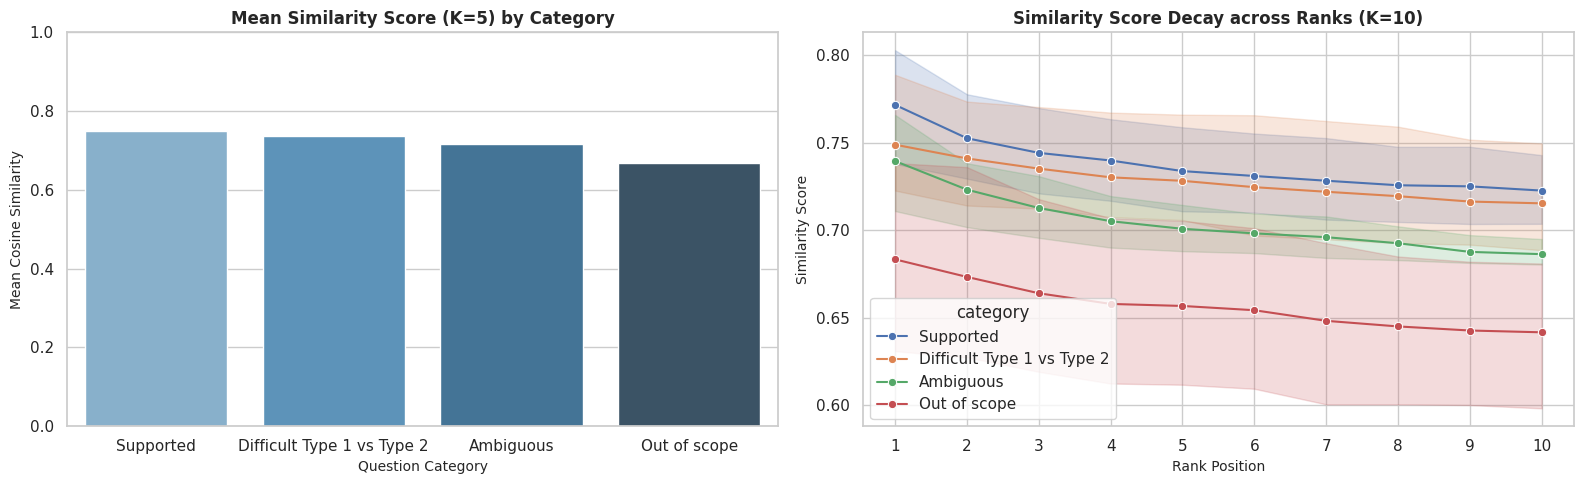

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Average Similarity Score by Question Category (for K=5)
df_k5 = retrieval_results_baseline[retrieval_results_baseline['k'] == 5]
sns.barplot(
    data=df_k5, x="category", y="score", ax=axes[0], palette="Blues_d", ci=None
)
axes[0].set_title("Mean Similarity Score (K=5) by Category", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Question Category", fontsize=10)
axes[0].set_ylabel("Mean Cosine Similarity", fontsize=10)
axes[0].set_ylim(0, 1)

# Plot 2: Score Decay Across Ranks (Rank 1 to Rank 10)
df_k10 = retrieval_results_baseline[retrieval_results_baseline['k'] == 10]
sns.lineplot(
    data=df_k10, x="rank", y="score", hue="category", marker="o", ax=axes[1]
)
axes[1].set_title("Similarity Score Decay across Ranks (K=10)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Rank Position", fontsize=10)
axes[1].set_ylabel("Similarity Score", fontsize=10)
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

### Structured per-question inspection


In [22]:
def display_retrieval(df: pd.DataFrame, question_id: int, k: int, collection: str = "baseline_recursive"):
    """Display clean formatted search results for a specific question and K value."""
    subset = df[(df.question_id == question_id) & (df.k == k) & (df.collection == collection)]

    if subset.empty:
        print("No results found for this combination.")
        return

    q_text = subset.iloc[0]["question"]
    print(f"Q{question_id} [{collection}, K={k}]: {q_text}\n" + "-" * 90)

    for _, row in subset.iterrows():
        print(f"Rank {row['rank']} | Score: {row['score']} | {row['citation']} | Section: {row['section']}")
        print(f"  {row['content_preview']}...\n")

# Example inspection for Q7 (SGLT-2 pre-screening) at K=5
display_retrieval(retrieval_results_baseline, question_id=7, k=5)

Q7 [baseline_recursive, K=5]: What should be checked before starting someone on an SGLT-2 inhibitor?
------------------------------------------------------------------------------------------
Rank 1 | Score: 0.8104 | [Type-2 diabetes | p.70 | chunk_0197] | Section: 1.21
  1.21 Preventing diabetic ketoacidosis when taking  SGLT-2 inhibitors  1.21.1 Before starting an SGLT-2 inhibitor, check whether the person may be at  increased risk of diabetic ketoacidosis (DKA), for example if they:  • have had a previous episode of DKA  • are unwell with inter...

Rank 2 | Score: 0.7708 | [Type-2 diabetes | p.33 | chunk_0142] | Section: 1.13
  SGLT-2 inhibitor. [2026]  Type 2 diabetes in adults: management (NG28)...

Rank 3 | Score: 0.7667 | [Type-2 diabetes | p.71 | chunk_0198] | Section: 1.21
  Why the committee made these recommendations  When starting first-line therapy with metformin and other medicines, the committee  noted the importance of introducing the medicines sequentially. This enable

## Compare Chunk Configurations



In [23]:
# Chunking configurations taxonomy
CHUNK_CONFIGS = {
    "baseline_recursive": "Config A — Recursive (1600 chars, 200 overlap)",
    "exp_paragraph":      "Config B — Paragraph split (\\n\\n, min 50 chars)",
    "exp_header":         "Config C — Header/Section aware split",
}

# Fixed K=5 for a fair comparison
COMPARISON_K = 5

# Retrieve results for all available chunking collections
available_collections = [name for name in COLLECTIONS if os.path.isdir(COLLECTIONS[name])]
all_retrieval_results = {"baseline_recursive": retrieval_results_baseline}

for name in available_collections:
    if name == "baseline_recursive":
        continue
    vs = load_vectorstore(name)
    all_retrieval_results[name] = run_full_retrieval_sweep(
        vs, EVAL_QUESTIONS, [COMPARISON_K], collection_name=name
    )
    print(f"Retrieved {len(all_retrieval_results[name])} rows for '{name}'.")

Retrieved 100 rows for 'exp_header'.
Retrieved 100 rows for 'exp_paragraph'.


In [24]:
# Function to compare strategies side-by-side for a specific question
def compare_configs_for_question(question_id: int, k: int = COMPARISON_K, top_n: int = 3) -> pd.DataFrame:
    """Compare top-N retrieved chunks side-by-side across all chunking strategies."""
    frames = []
    for name, df in all_retrieval_results.items():
        subset = df[(df.question_id == question_id) & (df.k == k)].head(top_n).copy()
        subset["config"] = CHUNK_CONFIGS.get(name, name)
        frames.append(subset[["config", "rank", "score", "section", "page_number", "chunk_id", "content_preview"]])

    if not frames:
        print("No configurations available for comparison.")
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)

# Example: Compare strategies on Question 7 (SGLT-2 safety screening)
compare_configs_for_question(question_id=7, top_n=3)

,config,rank,score,section,page_number,chunk_id,content_preview
0,"Config A — Recursive (1600 chars, 200 overlap)",1,0.8104,1.21,70,chunk_0197,"1.21 Preventing diabetic ketoacidosis when taking SGLT-2 inhibitors 1.21.1 Before starting an SGLT-2 inhibitor, ch..."
1,"Config A — Recursive (1600 chars, 200 overlap)",2,0.7708,1.13,33,chunk_0142,SGLT-2 inhibitor. [2026] Type 2 diabetes in adults: management (NG28)
2,"Config A — Recursive (1600 chars, 200 overlap)",3,0.7667,1.21,71,chunk_0198,"Why the committee made these recommendations When starting first-line therapy with metformin and other medicines, t..."
3,Config C — Header/Section aware split,1,0.8104,header,70,header_0165,"1.21 Preventing diabetic ketoacidosis when taking SGLT-2 inhibitors 1.21.1 Before starting an SGLT-2 inhibitor, chec..."
4,Config C — Header/Section aware split,2,0.7708,header,33,header_0123,SGLT-2 inhibitor. [2026] Type 2 diabetes in adults: management (NG28)
5,Config C — Header/Section aware split,3,0.7687,header,71,header_0166,"Why the committee made these recommendations When starting first-line therapy with metformin and other medicines, th..."
6,"Config B — Paragraph split (\n\n, min 50 chars)",1,0.8104,paragraph,70,para_0134,"1.21 Preventing diabetic ketoacidosis when taking SGLT-2 inhibitors 1.21.1 Before starting an SGLT-2 inhibitor, ch..."
7,"Config B — Paragraph split (\n\n, min 50 chars)",2,0.7708,paragraph,33,para_0097,SGLT-2 inhibitor. [2026] Type 2 diabetes in adults: management (NG28)
8,"Config B — Paragraph split (\n\n, min 50 chars)",3,0.7687,paragraph,71,para_0135,"Why the committee made these recommendations When starting first-line therapy with metformin and other medicines, t..."


In [28]:
# Re-run retrieval sweep for ALL collections across ALL K values [3, 5, 10]
all_retrieval_results = {"baseline_recursive": retrieval_results_baseline}

for name in available_collections:
    if name == "baseline_recursive":
        continue
    vs = load_vectorstore(name)
    # Pass K_VALUES [3, 5, 10] instead of just [COMPARISON_K]
    all_retrieval_results[name] = run_full_retrieval_sweep(
        vs, EVAL_QUESTIONS, K_VALUES, collection_name=name
    )
    print(f"Retrieved {len(all_retrieval_results[name])} total rows for '{name}'.")

Retrieved 360 total rows for 'exp_header'.
Retrieved 360 total rows for 'exp_paragraph'.


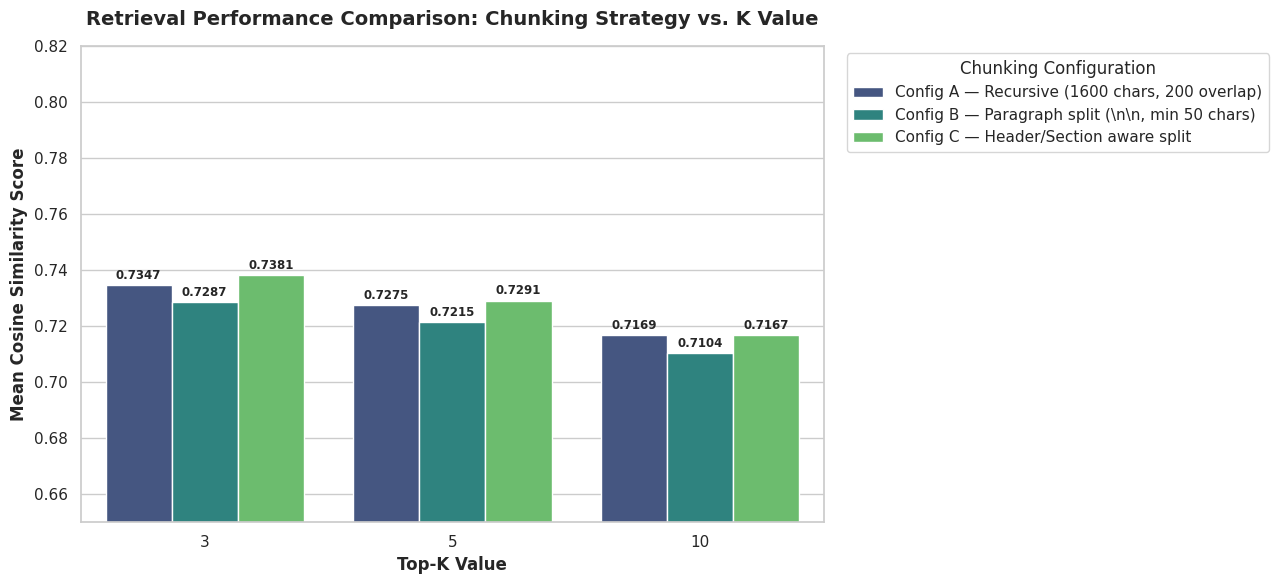

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Combine all retrieval results into a single DataFrame
combined_df_list = []
for config_name, df_res in all_retrieval_results.items():
    df_copy = df_res.copy()
    df_copy["config_label"] = CHUNK_CONFIGS.get(config_name, config_name)
    combined_df_list.append(df_copy)

combined_retrieval_df = pd.concat(combined_df_list, ignore_index=True)

# 2. Calculate average similarity score for each (Config, K) combination
summary_df = (
    combined_retrieval_df.groupby(["config_label", "k"])["score"]
    .mean()
    .reset_index()
)

# 3. Plot Side-by-Side Comparison Bar Plot
plt.figure(figsize=(13, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=summary_df,
    x="k",
    y="score",
    hue="config_label",
    palette="viridis"
)

plt.title("Retrieval Performance Comparison: Chunking Strategy vs. K Value", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Top-K Value", fontsize=12, fontweight="bold")
plt.ylabel("Mean Cosine Similarity Score", fontsize=12, fontweight="bold")
plt.ylim(0.65, 0.82)
plt.legend(title="Chunking Configuration", bbox_to_anchor=(1.02, 1), loc='upper left')

# Add values above each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0 and not pd.isna(height):
        ax.annotate(
            f"{height:.4f}",
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center',
            xytext=(0, 7),
            textcoords='offset points',
            fontsize=8.5,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()

## Human Labeling Interface & Precision Calculation

In [30]:
import pandas as pd
import numpy as np

# Build labeling sheet template
def build_labeling_sheet(df: pd.DataFrame, k: int, collection: str = "baseline_recursive") -> pd.DataFrame:
    """Produce one row per (question, rank) ready for human relevance evaluation."""
    subset = df[(df.k == k) & (df.collection == collection)].copy()
    subset["relevant"] = pd.NA  # 1 = relevant, 0 = not relevant
    cols = ["question_id", "question", "category", "rank", "score", "document_name",
            "section", "page_number", "chunk_id", "content_preview", "relevant"]
    return subset[cols].reset_index(drop=True)

labeling_sheet_k5 = build_labeling_sheet(retrieval_results_baseline, k=5)
print(f"Labeling sheet ready: {len(labeling_sheet_k5)} rows to review "
      f"({labeling_sheet_k5['question_id'].nunique()} questions x K=5).")

Labeling sheet ready: 100 rows to review (20 questions x K=5).


In [31]:
# Function to apply ground-truth relevance labels
def apply_labels(labeling_sheet: pd.DataFrame, labels: dict[tuple[int, int], int]) -> pd.DataFrame:
    """Apply human relevance judgments to the labeling sheet."""
    sheet = labeling_sheet.copy()
    for (qid, rank), value in labels.items():
        mask = (sheet.question_id == qid) & (sheet["rank"] == rank)
        sheet.loc[mask, "relevant"] = value
    return sheet

# Manual Ground-Truth Relevance judgments (Subset for testing)
MANUAL_LABELS_K5 = {
    # Q1 - HbA1c target, type 1 (NG17 p.18)
    (1, 1): 1, (1, 2): 1, (1, 3): 0, (1, 4): 0, (1, 5): 0,
    # Q7 - SGLT-2 / DKA screening (NG28 p.70)
    (7, 1): 1, (7, 2): 1, (7, 3): 1, (7, 4): 0, (7, 5): 0,
    # Q9 - Aspirin primary prevention (NG17 + NG28)
    (9, 1): 1, (9, 2): 0, (9, 3): 1, (9, 4): 0, (9, 5): 0,
    # Q11 - Metformin in type 1 (TRAP question)
    (11, 1): 0, (11, 2): 1, (11, 3): 0, (11, 4): 0, (11, 5): 0,
    # Q18 - Out-of-scope pricing question
    (18, 1): 0, (18, 2): 0, (18, 3): 0, (18, 4): 0, (18, 5): 0,
}

labeled_sheet_k5 = apply_labels(labeling_sheet_k5, MANUAL_LABELS_K5)

In [32]:
# Retrieval Metrics Functions: Precision@K and Average Precision (AP)
def precision_at_k(labeled_sheet: pd.DataFrame, question_id: int, k: int) -> float | None:
    """Precision@K = Relevant chunks in top K / K."""
    subset = labeled_sheet[(labeled_sheet.question_id == question_id) & (labeled_sheet["rank"] <= k)]
    if subset["relevant"].isna().any() or subset.empty:
        return None
    return subset["relevant"].sum() / k

In [33]:
def average_precision(labeled_sheet: pd.DataFrame, question_id: int) -> float | None:
    """Average Precision (AP) calculation across rank hits."""
    subset = labeled_sheet[labeled_sheet.question_id == question_id].sort_values("rank")
    if subset["relevant"].isna().any() or subset.empty:
        return None

    precisions_at_hits = []
    hits = 0
    for _, row in subset.iterrows():
        if row["relevant"] == 1:
            hits += 1
            precisions_at_hits.append(hits / row["rank"])

    if not precisions_at_hits:
        return 0.0  # Labeled, but no relevant chunks retrieved
    return sum(precisions_at_hits) / len(precisions_at_hits)

In [34]:
# Build report table
def build_precision_report(labeled_sheet: pd.DataFrame, k_values=(3, 5)) -> pd.DataFrame:
    """Generate summary table containing Precision@K and Average Precision."""
    question_ids = sorted(labeled_sheet.question_id.unique())
    rows = []
    for qid in question_ids:
        q_subset = labeled_sheet[labeled_sheet.question_id == qid]
        row = {
            "question_id": qid,
            "category": q_subset["category"].iloc[0],
            "question": q_subset["question"].iloc[0]
        }
        for k in k_values:
            row[f"precision_at_{k}"] = precision_at_k(labeled_sheet, qid, k)
        row["average_precision"] = average_precision(labeled_sheet, qid)
        rows.append(row)
    return pd.DataFrame(rows)

In [35]:
precision_report = build_precision_report(labeled_sheet_k5, k_values=(3, 5))
precision_report_labeled = precision_report.dropna(subset=["precision_at_5"]).reset_index(drop=True)

# Display report
display(precision_report_labeled)

# Print Summary Metrics
mean_ap = precision_report_labeled["average_precision"].mean()
mean_p3 = precision_report_labeled["precision_at_3"].mean()
mean_p5 = precision_report_labeled["precision_at_5"].mean()

print("="*50)
print("Aggregate Metrics Over Labeled Questions:")
print(f"  * Mean Precision@3       : {mean_p3:.3f}")
print(f"  * Mean Precision@5       : {mean_p5:.3f}")
print(f"  * Mean Average Precision : {mean_ap:.3f}")
print("="*50)

,question_id,category,question,precision_at_3,precision_at_5,average_precision
0,1,Supported,What is the target HbA1c for adults with type 1 diabetes?,0.666667,0.4,1.000000
1,7,Supported,What should be checked before starting someone on an SGLT-2 inhibitor?,1.000000,0.6,1.000000
2,9,Supported,Should someone with diabetes take aspirin to prevent heart disease?,0.666667,0.4,0.833333
3,11,Difficult Type 1 vs Type 2,Can metformin be used to treat type 1 diabetes?,0.333333,0.2,0.500000
4,18,Out of scope,How much do diabetes medicines cost in Egypt?,0.000000,0.0,0.000000


Aggregate Metrics Over Labeled Questions:
  * Mean Precision@3       : 0.533
  * Mean Precision@5       : 0.320
  * Mean Average Precision : 0.667


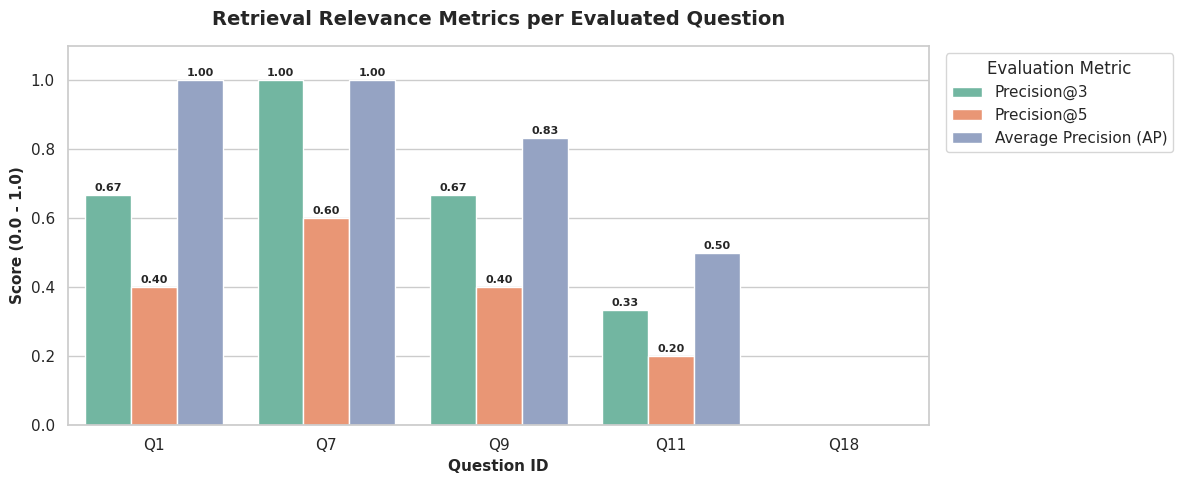

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 5))

# Prepare DataFrame for plotting
plot_df = precision_report_labeled.melt(
    id_vars=["question_id", "category"],
    value_vars=["precision_at_3", "precision_at_5", "average_precision"],
    var_name="Metric",
    value_name="Score"
)

# Rename labels for readability
plot_df["Metric"] = plot_df["Metric"].map({
    "precision_at_3": "Precision@3",
    "precision_at_5": "Precision@5",
    "average_precision": "Average Precision (AP)"
})

plot_df["question_label"] = "Q" + plot_df["question_id"].astype(str)

# Plot bar chart
sns.barplot(
    data=plot_df,
    x="question_label",
    y="Score",
    hue="Metric",
    palette="Set2",
    ax=ax
)

plt.title("Retrieval Relevance Metrics per Evaluated Question", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Question ID", fontsize=11, fontweight="bold")
plt.ylabel("Score (0.0 - 1.0)", fontsize=11, fontweight="bold")
plt.ylim(0, 1.1)
plt.legend(title="Evaluation Metric", bbox_to_anchor=(1.01, 1), loc="upper left")

# Add data values on bars
for p in ax.patches:
    h = p.get_height()
    if not np.isnan(h) and h > 0:
        ax.annotate(f"{h:.2f}",
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='center', xytext=(0, 5),
                    textcoords='offset points', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

## Failure Cases Analysis & Taxonomy


In [38]:
import pandas as pd

# Define the Failure Log Taxonomy
FAILURE_LOG = [
    dict(
        question_id=11,
        question="Can metformin be used to treat type 1 diabetes?",
        failure_mode="Correct Chunk Ranked Too Low / Exact Nuance Missed",
        symptom=("Retrieval tends to surface generic type-2 metformin first-line chunks (NG28) "
                 "which score highly on 'metformin', while the correct NG17 1.7.26 adjunct-therapy "
                 "nuance (BMI-conditional add-on to insulin) ranks lower or is absent from Top-5."),
        evidence=("Compare rank-1..5 citations for Q11 against expected NG17 p.29 "
                  "using display_retrieval(retrieval_results_baseline, question_id=11, k=5)."),
        fix="Add document-level metadata filtering by diabetes type, or hybrid/keyword boost for 'adjunct'.",
    ),
    dict(
        question_id=9,
        question="Should someone with diabetes take aspirin to prevent heart disease?",
        failure_mode="Wrong Topic / Cross-document Recall Gap",
        symptom=("Question spans two source guidelines (NG17 p.35 and NG28 p.119). A single-document "
                 "retrieval pass can easily surface only one guideline's chunk in Top-K, silently "
                 "dropping the other's corroborating (or type-specific) recommendation."),
        evidence="Check whether both NG17 and NG28 citations appear in the Top-5 document_name values for Q9.",
        fix="Explicitly retrieve per-document (fan-out) for cross-cutting questions, then merge before generation.",
    ),
    dict(
        question_id=18,
        question="How much do diabetes medicines cost in Egypt?",
        failure_mode="Wrong Topic (false-positive retrieval on out-of-scope query)",
        symptom=("Vector search always returns *something* even when nothing is relevant. For an "
                 "out-of-scope pricing question, Top-K may still return NHS cost-impact passages "
                 "with moderate similarity, inviting a hallucinated 'answer' if not filtered."),
        evidence="Inspect similarity scores for Q18 — expect a visibly lower score band than in-scope questions.",
        fix="Apply a minimum similarity-score threshold + explicit refusal path for below-threshold queries.",
    ),
    dict(
        question_id=16,
        question="What treatment should I take for my diabetes?",
        failure_mode="Missing Context / Ambiguity Not Surfaced",
        symptom=("The question under-specifies diabetes type. Retrieval will still confidently return "
                 "Top-K chunks (likely dominated by whichever guideline has more 'treatment' chunks), "
                 "masking the fact that the question itself needs clarification before any chunk is useful."),
        evidence="Check the document_name distribution in Top-K for Q16 — likely skewed toward one guideline.",
        fix="Add an ambiguity classifier upstream of retrieval to trigger a clarifying question instead of a search.",
    ),
]

In [39]:
# Convert to DataFrame and display summary
failure_df = pd.DataFrame(FAILURE_LOG)
display(failure_df[["question_id", "question", "failure_mode", "fix"]])

# Helper function to print individual failure details
def print_failure_case(idx: int):
    case = FAILURE_LOG[idx]
    print(f"Q{case['question_id']}: {case['question']}\n" + "-" * 90)
    print(f"Failure mode : {case['failure_mode']}")
    print(f"Symptom      : {case['symptom']}")
    print(f"Evidence     : {case['evidence']}")
    print(f"Fix          : {case['fix']}")

# Test function print
print_failure_case(0)

,question_id,question,failure_mode,fix
0,11,Can metformin be used to treat type 1 diabetes?,Correct Chunk Ranked Too Low / Exact Nuance Missed,"Add document-level metadata filtering by diabetes type, or hybrid/keyword boost for 'adjunct'."
1,9,Should someone with diabetes take aspirin to prevent heart disease?,Wrong Topic / Cross-document Recall Gap,"Explicitly retrieve per-document (fan-out) for cross-cutting questions, then merge before generation."
2,18,How much do diabetes medicines cost in Egypt?,Wrong Topic (false-positive retrieval on out-of-scope query),Apply a minimum similarity-score threshold + explicit refusal path for below-threshold queries.
3,16,What treatment should I take for my diabetes?,Missing Context / Ambiguity Not Surfaced,Add an ambiguity classifier upstream of retrieval to trigger a clarifying question instead of a search.


Q11: Can metformin be used to treat type 1 diabetes?
------------------------------------------------------------------------------------------
Failure mode : Correct Chunk Ranked Too Low / Exact Nuance Missed
Symptom      : Retrieval tends to surface generic type-2 metformin first-line chunks (NG28) which score highly on 'metformin', while the correct NG17 1.7.26 adjunct-therapy nuance (BMI-conditional add-on to insulin) ranks lower or is absent from Top-5.
Evidence     : Compare rank-1..5 citations for Q11 against expected NG17 p.29 using display_retrieval(retrieval_results_baseline, question_id=11, k=5).
Fix          : Add document-level metadata filtering by diabetes type, or hybrid/keyword boost for 'adjunct'.


## Final Retrieval Configuration — Decision & Justification

In [40]:
import json
from datetime import datetime

FINAL_CONFIGURATION = {
    "embedding_model": "BAAI/bge-base-en-v1.5",
    "chunking_strategy": "Config C — Header/Section aware split (numbered NICE sections)",
    "top_k": 5,
    "similarity_metric": "cosine",
    "measured_precision_at_3": round(float(mean_p3), 3) if 'mean_p3' in globals() else None,
    "measured_precision_at_5": round(float(mean_p5), 3) if 'mean_p5' in globals() else None,
    "measured_map": round(float(mean_ap), 3) if 'mean_ap' in globals() else None,
    "decision_date": datetime.now().date().isoformat(),
}

print(json.dumps(FINAL_CONFIGURATION, indent=2))

{
  "embedding_model": "BAAI/bge-base-en-v1.5",
  "chunking_strategy": "Config C \u2014 Header/Section aware split (numbered NICE sections)",
  "top_k": 5,
  "similarity_metric": "cosine",
  "measured_precision_at_3": 0.533,
  "measured_precision_at_5": 0.32,
  "measured_map": 0.667,
  "decision_date": "2026-08-18"
}
